# 🦟 Malaria Prediction Using Machine Learning

## Project Objective

This project predicts whether a patient has:

- **0 → Non-Severe Malaria**
- **1 → Severe Malaria**

The project follows these steps:

1. Load the dataset
2. Understand the data
3. Check missing values
4. Remove duplicate records
5. Perform data analysis
6. Select useful features
7. Split the data
8. Scale the features
9. Train Machine Learning models
10. Evaluate the models
11. Handle class imbalance
12. Train balanced models
13. Explain predictions using LIME
14. Explain the model using SHAP
15. Select the best model
16. Save the final model
17. Make a final prediction

### Target Column

The target column is:

`severe_maleria`

## Cell 2 — Import Required Libraries

In this cell, we import the basic Python libraries.

### Libraries used

- NumPy → numerical calculations
- Pandas → working with datasets
- Matplotlib → graphs
- Seaborn → statistical graphs
- Missingno → visualizing missing values
- OS → working with files and folders

In [1]:
%pip install missingno

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# CELL 1 - IMPORT LIBRARIES
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# ============================================================
# CELL 2 - LOAD DATASET
# ============================================================

DATA_FILE = "Malaria-Data.csv"

print("Current folder:")
print(os.getcwd())

print("\nFiles available:")
print(os.listdir())

Current folder:
C:\Users\pamba

Files available:
['.anaconda', '.conda', '.continuum', '.copilot', '.gemini', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.python_history', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Explainable-Machine-Learning-Model-for-Malaria-Classification-with-Improved-Accuracy', 'Favorites', 'Links', 'Local Settings', 'Malaria-Data.csv', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{d9f5d191-907a-11f0-b65f-502e9111542b}.TM.blf', 'NTUSER.DAT{d9f5d191-907a-11f0-b65f-502e9111542b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{d9f5d191-907a-11f0-b65f-502e9111542b}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'project.ipynb', 'project1.ipynb', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'Untitled1.ipynb', 'Videos']


In [6]:
# ============================================================
# CELL 3 - READ DATASET
# ============================================================

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 337
Columns: 18


,age,sex,fever,cold,rigor,fatigue,headace,bitter_tongue,vomitting,diarrhea,Convulsion,Anemia,jundice,cocacola_urine,hypoglycemia,prostraction,hyperpyrexia,severe_maleria
0,3,1,1,1,0,1,1,1,0,1,1,0,1,1,1,0,0,0
1,3,0,1,1,1,1,1,1,0,1,0,0,0,1,1,0,0,0
2,3,0,1,1,1,1,1,0,0,1,1,0,0,1,1,0,0,1
3,4,1,1,1,0,1,0,0,0,0,0,0,1,0,1,0,1,0
4,4,0,1,1,1,0,1,0,0,0,1,0,1,1,1,0,0,0


In [7]:
# ============================================================
# CELL 4 - CHECK MISSING VALUES
# ============================================================

missing_values = df.isnull().sum()

display(
    missing_values.to_frame(
        name="Missing Values"
    )
)

,Missing Values
age,0
sex,0
fever,0
cold,0
rigor,0
fatigue,0
headace,0
bitter_tongue,0
vomitting,0
diarrhea,0


## Cell 5 — View Dataset Information

Now we check the structure of the dataset.

`df.info()` shows:

- Column names
- Number of rows
- Data types
- Non-null values

This helps us understand the dataset before preprocessing.

In [8]:
# ============================================================
# CELL 6 - DATASET INFORMATION
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             337 non-null    int64
 1   sex             337 non-null    int64
 2   fever           337 non-null    int64
 3   cold            337 non-null    int64
 4   rigor           337 non-null    int64
 5   fatigue         337 non-null    int64
 6   headace         337 non-null    int64
 7   bitter_tongue   337 non-null    int64
 8   vomitting       337 non-null    int64
 9   diarrhea        337 non-null    int64
 10  Convulsion      337 non-null    int64
 11  Anemia          337 non-null    int64
 12  jundice         337 non-null    int64
 13  cocacola_urine  337 non-null    int64
 14  hypoglycemia    337 non-null    int64
 15  prostraction    337 non-null    int64
 16  hyperpyrexia    337 non-null    int64
 17  severe_maleria  337 non-null    int64
dtypes: int64(18)
memory usage: 47.5 KB


## Cell 7 — Display Column Names

We display all column names.

The target column for this project is:

`severe_maleria`

In [9]:
# ============================================================
# CELL 8 - COLUMN NAMES
# ============================================================

print("Columns in the dataset:")

for column in df.columns:
    print(column)

Columns in the dataset:
age
sex
fever
cold
rigor
fatigue
headace
bitter_tongue
vomitting
diarrhea
Convulsion
Anemia
jundice
cocacola_urine
hypoglycemia
prostraction
hyperpyrexia
severe_maleria


## Cell 9 — Define Target Variable

The target variable is the value that our Machine Learning
model will predict.

Target:

`severe_maleria`

The expected classes are:

- 0 → Non-Severe Malaria
- 1 → Severe Malaria

In [10]:
# ============================================================
# CELL 10 - DEFINE TARGET
# ============================================================

TARGET = "severe_maleria"

if TARGET not in df.columns:
    raise ValueError(
        f"'{TARGET}' was not found in the dataset."
    )

print("Target column:", TARGET)

print("\nTarget distribution:")
print(df[TARGET].value_counts())

Target column: severe_maleria

Target distribution:
severe_maleria
0    221
1    116
Name: count, dtype: int64


## Cell 11 — Check Duplicate Rows

Duplicate rows mean that the same patient record
may appear more than once.

We check how many duplicate records are present.

In [11]:
# ============================================================
# CELL 12 - CHECK DUPLICATES
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## Cell 13 — Remove Duplicate Rows

If duplicate records exist, we remove them.

After removing duplicates, we reset the DataFrame index.

In [12]:
# ============================================================
# CELL 14 - REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()

df = df.reset_index(drop=True)

print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(337, 18)


## Cell 15 — Handle Missing Values

Machine Learning models need usable values.

For numerical columns, we replace missing values
with the median of that column.

The median is useful because it is less affected
by extreme values than the mean.

In [13]:
# ============================================================
# CELL 16 - HANDLE MISSING VALUES
# ============================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

print("Missing values after treatment:")

display(
    df.isnull().sum().to_frame(
        name="Missing Values"
    )
)

Missing values after treatment:


,Missing Values
age,0
sex,0
fever,0
cold,0
rigor,0
fatigue,0
headace,0
bitter_tongue,0
vomitting,0
diarrhea,0


## Cell 17 — Descriptive Statistics

We use `describe()` to understand the numerical data.

It gives us:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

In [14]:
# ============================================================
# CELL 18 - DESCRIPTIVE STATISTICS
# ============================================================

display(df.describe())

,age,sex,fever,cold,rigor,fatigue,headace,bitter_tongue,vomitting,diarrhea,Convulsion,Anemia,jundice,cocacola_urine,hypoglycemia,prostraction,hyperpyrexia,severe_maleria
count,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000,337.000000
mean,30.347181,0.534125,0.750742,0.566766,0.341246,0.483680,0.700297,0.403561,0.074184,0.338279,0.344214,0.350148,0.658754,0.540059,0.857567,0.219585,0.139466,0.344214
std,14.720853,0.499576,0.433227,0.496259,0.474833,0.500477,0.458809,0.491341,0.262460,0.473828,0.475818,0.477726,0.474833,0.499134,0.350014,0.414581,0.346947,0.475818
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,29.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,38.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,77.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Cell 19 — Target Distribution

Now we check how many patients belong to each class.

0 → Non-Severe Malaria

1 → Severe Malaria

If one class has many more records than the other,
the dataset is imbalanced.

In [15]:
# ============================================================
# CELL 20 - TARGET DISTRIBUTION
# ============================================================

print(
    df[TARGET].value_counts()
)

severe_maleria
0    221
1    116
Name: count, dtype: int64


## Cell 21 — Target Distribution Graph

A bar chart makes the number of patients
in each class easier to understand.

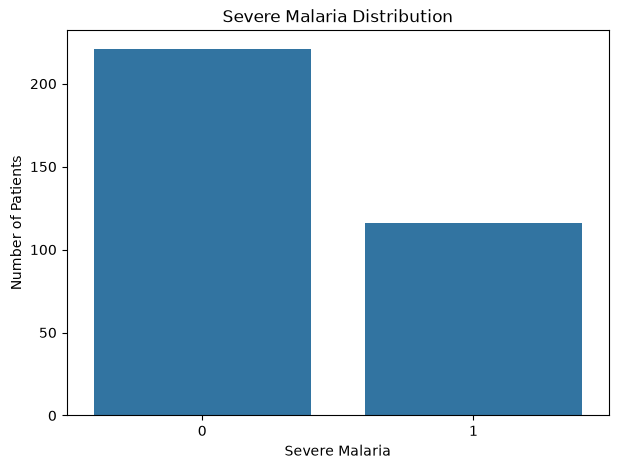

In [16]:
# ============================================================
# CELL 22 - TARGET DISTRIBUTION GRAPH
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    x=TARGET,
    data=df
)

plt.title("Severe Malaria Distribution")
plt.xlabel("Severe Malaria")
plt.ylabel("Number of Patients")

plt.show()

## Cell 23 — Target Percentages

Now we calculate the percentage of patients
in each target class.

This helps us understand the class imbalance
more clearly.

In [17]:
# ============================================================
# CELL 24 - TARGET PERCENTAGES
# ============================================================

target_percentage = (
    df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(
    target_percentage.to_frame(
        name="Percentage"
    )
)

,Percentage
severe_maleria,
0,65.58
1,34.42


## Cell 25 — Correlation Analysis

Correlation tells us how strongly numerical variables
are related.

The values are approximately between:

- -1 → negative relationship
- 0 → little/no linear relationship
- +1 → positive relationship

We will use this information to understand
which features may be useful for prediction.

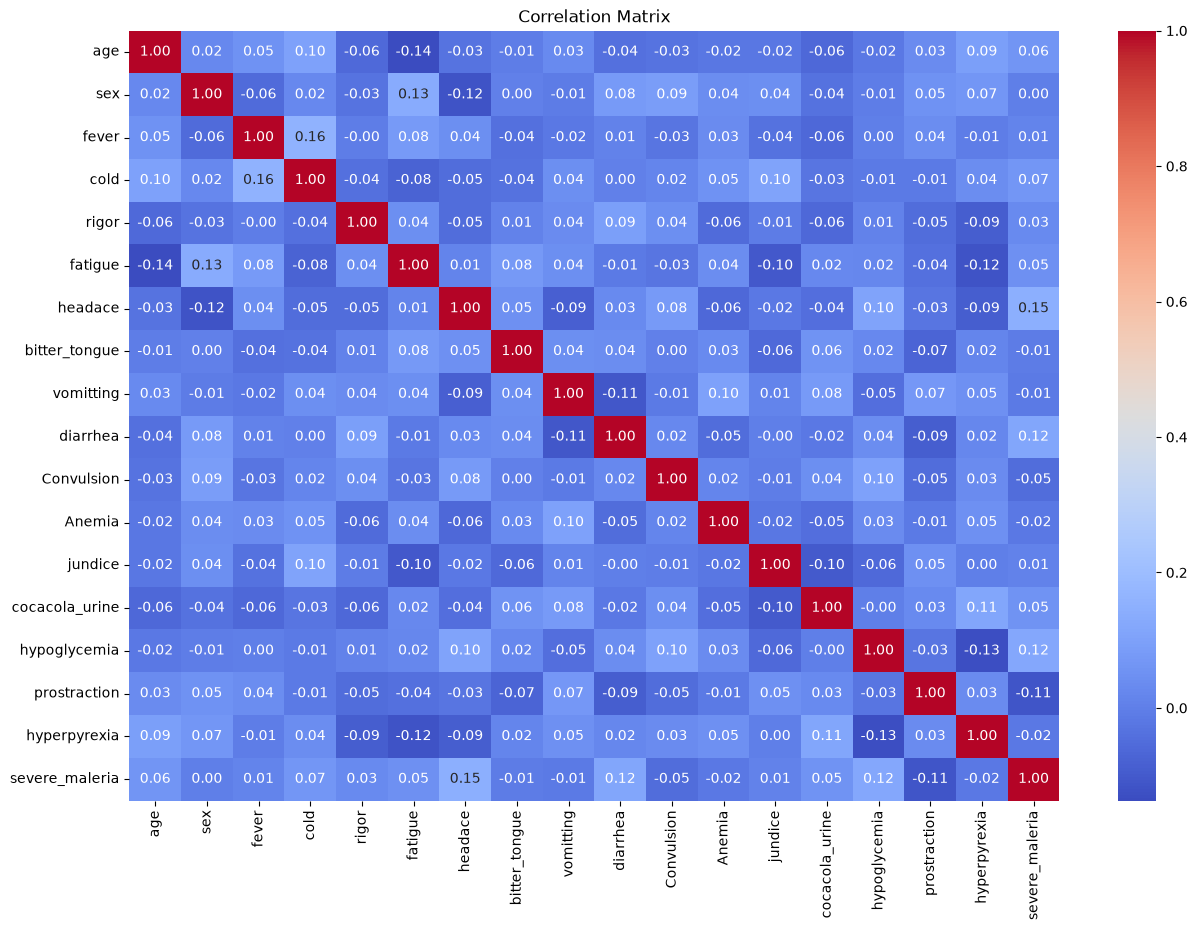

In [18]:
# ============================================================
# CELL 26 - CORRELATION MATRIX
# ============================================================

correlation_matrix = df.corr(
    numeric_only=True
)

plt.figure(figsize=(15, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Cell 27 — Correlation With Target

Now we check the correlation of every numerical feature
with `severe_maleria`.

This helps us identify features that may be useful
for the Machine Learning model.

In [19]:
# ============================================================
# CELL 28 - TARGET CORRELATION
# ============================================================

target_correlation = (
    correlation_matrix[TARGET]
    .sort_values(
        ascending=False
    )
)

display(target_correlation)

severe_maleria    1.000000
headace           0.146766
hypoglycemia      0.116556
diarrhea          0.115634
cold              0.066237
age               0.061919
cocacola_urine    0.054551
fatigue           0.048656
rigor             0.031818
fever             0.013195
jundice           0.007700
sex               0.000520
bitter_tongue    -0.010350
vomitting        -0.014426
Anemia           -0.021174
hyperpyrexia     -0.021238
Convulsion       -0.051646
prostraction     -0.112729
Name: severe_maleria, dtype: float64

## Cell 29 — Prepare Features and Target

Now we separate the dataset into two parts.

### X — Features

`X` contains the input variables that the model will use
to make predictions.

### y — Target

`y` contains the value we want to predict:

`severe_maleria`

So:

X → Patient information

y → Severe Malaria result

In [20]:
# ============================================================
# CELL 30 - SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=[TARGET])

y = df[TARGET]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget values:")
print(y.value_counts())

Features shape: (337, 17)
Target shape: (337,)

Feature columns:
['age', 'sex', 'fever', 'cold', 'rigor', 'fatigue', 'headace', 'bitter_tongue', 'vomitting', 'diarrhea', 'Convulsion', 'Anemia', 'jundice', 'cocacola_urine', 'hypoglycemia', 'prostraction', 'hyperpyrexia']

Target values:
severe_maleria
0    221
1    116
Name: count, dtype: int64


## Cell 31 — Check Feature Data Types

Machine Learning models generally require numerical input.

Here we check whether our features contain:

- Numerical columns
- Text/categorical columns

If categorical columns exist, we will convert them into
numerical values before training the models.

In [21]:
# ============================================================
# CELL 32 - CHECK DATA TYPES
# ============================================================

print("Feature data types:")

display(X.dtypes.to_frame(name="Data Type"))

Feature data types:


,Data Type
age,int64
sex,int64
fever,int64
cold,int64
rigor,int64
fatigue,int64
headace,int64
bitter_tongue,int64
vomitting,int64
diarrhea,int64


## Cell 33 — Convert Categorical Features

If the dataset contains categorical/text columns,
we convert them into numerical columns using one-hot encoding.

`pd.get_dummies()` converts categories into 0 and 1.

If all columns are already numerical, this step will
not significantly change the data.

In [22]:
# ============================================================
# CELL 34 - ENCODE CATEGORICAL FEATURES
# ============================================================

X = pd.get_dummies(
    X,
    drop_first=True
)

print("Features after encoding:")
print(X.shape)

display(X.head())

Features after encoding:
(337, 17)


,age,sex,fever,cold,rigor,fatigue,headace,bitter_tongue,vomitting,diarrhea,Convulsion,Anemia,jundice,cocacola_urine,hypoglycemia,prostraction,hyperpyrexia
0,3,1,1,1,0,1,1,1,0,1,1,0,1,1,1,0,0
1,3,0,1,1,1,1,1,1,0,1,0,0,0,1,1,0,0
2,3,0,1,1,1,1,1,0,0,1,1,0,0,1,1,0,0
3,4,1,1,1,0,1,0,0,0,0,0,0,1,0,1,0,1
4,4,0,1,1,1,0,1,0,0,0,1,0,1,1,1,0,0


## Cell 35 — Convert Data to Numeric Format

After encoding categorical features, we make sure that
all feature values are numerical.

This is necessary before scaling and training
Machine Learning models.

In [23]:
# ============================================================
# CELL 36 - ENSURE NUMERIC FEATURES
# ============================================================

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

# Replace any new missing values created during conversion
X = X.fillna(X.median())

print("All feature columns are ready.")

print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

All feature columns are ready.
Number of features: 17
Number of samples: 337


## Cell 37 — Train/Test Split

We divide the dataset into two parts:

### Training data

Used by the Machine Learning model to learn patterns.

### Testing data

Used to evaluate how well the model performs
on unseen data.

We use:

80% → Training

20% → Testing

`stratify=y` keeps approximately the same class distribution
in both datasets.

In [24]:
# ============================================================
# IMPORT train_test_split
# ============================================================

from sklearn.model_selection import train_test_split

print("train_test_split imported successfully!")

train_test_split imported successfully!


In [25]:
# ============================================================
# CELL 38 - TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (269, 17)
Testing data: (68, 17)

Training target distribution:
severe_maleria
0    176
1     93
Name: count, dtype: int64

Testing target distribution:
severe_maleria
0    45
1    23
Name: count, dtype: int64


## Cell 39 — Feature Scaling

Machine Learning models can perform better when numerical
features are placed on a similar scale.

We use `StandardScaler`.

Important:
- Fit the scaler only on training data.
- Use the same scaler to transform testing data.
- This helps prevent data leakage.

In [26]:
# ============================================================
# CELL 40 - FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Feature scaling completed!
Training scaled shape: (269, 17)
Testing scaled shape: (68, 17)


## Cell 41 — Convert Scaled Data Back to DataFrames

`StandardScaler` returns NumPy arrays.

We convert them back into Pandas DataFrames so that
we can keep the feature names.

This will also make the data easier to use later
with LIME and SHAP.

In [27]:
# ============================================================
# CELL 42 - SCALED DATAFRAMES
# ============================================================

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Scaled DataFrames created successfully!")

display(X_train_scaled.head())

Scaled DataFrames created successfully!


,age,sex,fever,cold,rigor,fatigue,headace,bitter_tongue,vomitting,diarrhea,Convulsion,Anemia,jundice,cocacola_urine,hypoglycemia,prostraction,hyperpyrexia
104,-0.604974,0.884001,0.570196,0.831760,-0.715008,1.065327,0.633279,-0.812708,-0.28341,-0.691391,-0.732900,1.375672,-1.353358,0.904194,0.405589,-0.547281,-0.373939
42,-0.949320,-1.131221,-1.753784,-1.202271,-0.715008,1.065327,-1.579084,1.230455,-0.28341,-0.691391,1.364442,-0.726918,0.738903,0.904194,0.405589,1.827214,-0.373939
44,-0.949320,-1.131221,0.570196,0.831760,1.398586,1.065327,0.633279,-0.812708,-0.28341,1.446359,1.364442,-0.726918,0.738903,0.904194,0.405589,-0.547281,-0.373939
307,1.529972,-1.131221,0.570196,0.831760,-0.715008,-0.938679,-1.579084,1.230455,-0.28341,-0.691391,-0.732900,-0.726918,-1.353358,0.904194,0.405589,-0.547281,-0.373939
218,0.290326,-1.131221,0.570196,0.831760,-0.715008,-0.938679,0.633279,-0.812708,-0.28341,-0.691391,1.364442,-0.726918,0.738903,0.904194,0.405589,1.827214,-0.373939


## Cell 43 — Train Random Forest Model

Random Forest is an ensemble Machine Learning algorithm.

It creates multiple decision trees and combines their
predictions.

We will use Random Forest as our first model.

In [28]:
# ============================================================
# CELL 44 - RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(
    X_train_scaled,
    y_train
)

rf_predictions = rf_model.predict(
    X_test_scaled
)

rf_probabilities = rf_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


## Cell 45 — Evaluate Random Forest

We calculate several evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Balanced Accuracy
- Matthews Correlation Coefficient

These metrics help us understand the performance
of the model.

In [29]:
# ============================================================
# CELL 46 - RANDOM FOREST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    rf_predictions
)

rf_mcc = matthews_corrcoef(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")

print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1 Score:", round(rf_f1, 4))
print("ROC-AUC:", round(rf_auc, 4))
print(
    "Balanced Accuracy:",
    round(rf_balanced_accuracy, 4)
)
print("MCC:", round(rf_mcc, 4))

Random Forest Results
---------------------
Accuracy: 0.5294
Precision: 0.32
Recall: 0.3478
F1 Score: 0.3333
ROC-AUC: 0.5444
Balanced Accuracy: 0.485
MCC: -0.0294


## Cell 47 — Classification Report

The classification report gives detailed performance
for both classes.

For this project, recall for Severe Malaria is especially
important because we want to identify severe cases correctly.

In [30]:
# ============================================================
# CELL 48 - CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.65      0.62      0.64        45
           1       0.32      0.35      0.33        23

    accuracy                           0.53        68
   macro avg       0.49      0.49      0.48        68
weighted avg       0.54      0.53      0.53        68



## Cell 49 — Confusion Matrix

The confusion matrix shows how many predictions
were correct and incorrect.

It contains:

- True Negative
- False Positive
- False Negative
- True Positive

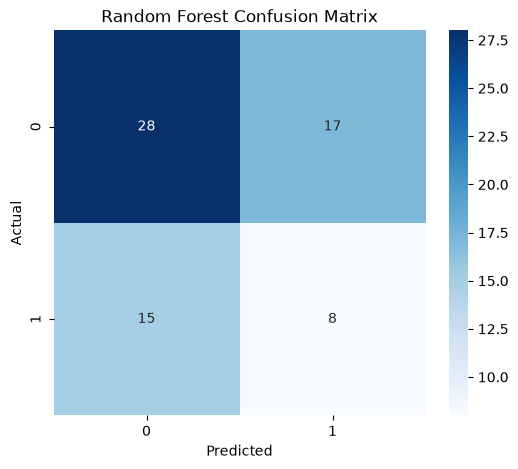

In [31]:
# ============================================================
# CELL 50 - CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Cell 51 — Random Forest Feature Importance

Random Forest can tell us which features contributed
most to the predictions.

A higher importance value means the feature had
a greater influence on the model.

In [32]:
# ============================================================
# CELL 52 - RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    feature_importance.head(20)
)

,Feature,Importance
0,age,0.255732
13,cocacola_urine,0.065483
3,cold,0.057085
12,jundice,0.055923
7,bitter_tongue,0.055068
11,Anemia,0.054298
9,diarrhea,0.049798
4,rigor,0.049782
1,sex,0.047951
5,fatigue,0.047855


## Cell 53 — Plot Top Feature Importance

Now we visualize the 15 most important features
identified by Random Forest.

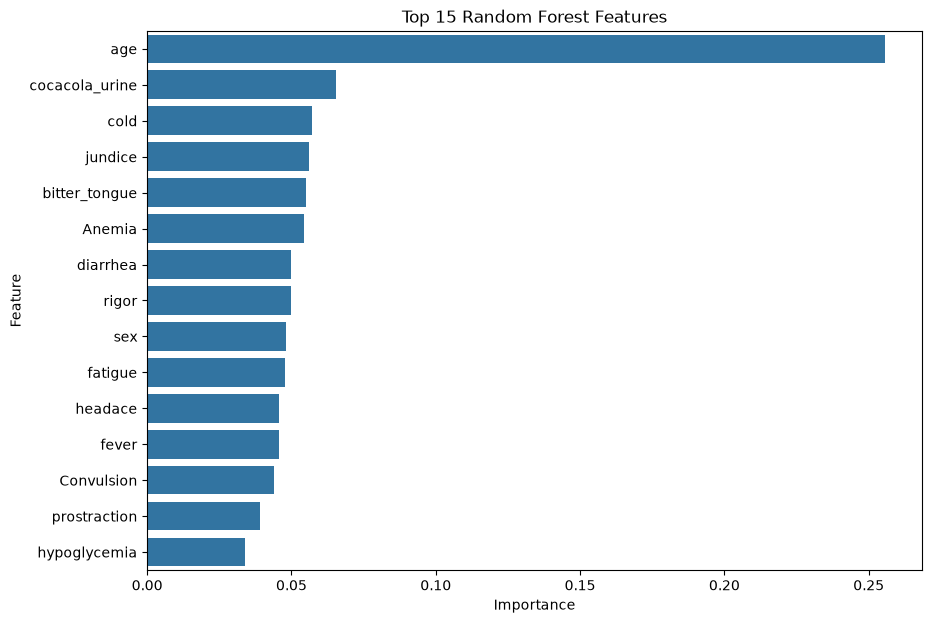

In [33]:
# ============================================================
# CELL 54 - FEATURE IMPORTANCE GRAPH
# ============================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Features")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

## Cell 55 — Train AdaBoost Model

AdaBoost is an ensemble Machine Learning algorithm.

It combines multiple weak learners and gives more importance
to observations that were previously classified incorrectly.

We train AdaBoost using the training data.

In [34]:
# ============================================================
# CELL 56 - ADABOOST MODEL
# ============================================================

from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(
    X_train_scaled,
    y_train
)

ada_predictions = ada_model.predict(
    X_test_scaled
)

ada_probabilities = ada_model.predict_proba(
    X_test_scaled
)[:, 1]

print("AdaBoost trained successfully!")

AdaBoost trained successfully!


## Cell 57 — Evaluate AdaBoost

We calculate the same evaluation metrics used for
Random Forest so that we can compare the models fairly.

In [35]:
# ============================================================
# CELL 58 - ADABOOST EVALUATION
# ============================================================

ada_accuracy = accuracy_score(
    y_test,
    ada_predictions
)

ada_precision = precision_score(
    y_test,
    ada_predictions,
    zero_division=0
)

ada_recall = recall_score(
    y_test,
    ada_predictions,
    zero_division=0
)

ada_f1 = f1_score(
    y_test,
    ada_predictions,
    zero_division=0
)

ada_auc = roc_auc_score(
    y_test,
    ada_probabilities
)

ada_balanced_accuracy = balanced_accuracy_score(
    y_test,
    ada_predictions
)

ada_mcc = matthews_corrcoef(
    y_test,
    ada_predictions
)

print("AdaBoost Results")
print("----------------")
print("Accuracy:", round(ada_accuracy, 4))
print("Precision:", round(ada_precision, 4))
print("Recall:", round(ada_recall, 4))
print("F1 Score:", round(ada_f1, 4))
print("ROC-AUC:", round(ada_auc, 4))
print(
    "Balanced Accuracy:",
    round(ada_balanced_accuracy, 4)
)
print("MCC:", round(ada_mcc, 4))

AdaBoost Results
----------------
Accuracy: 0.7059
Precision: 0.7143
Recall: 0.2174
F1 Score: 0.3333
ROC-AUC: 0.73
Balanced Accuracy: 0.5865
MCC: 0.2693


## Cell 59 — Train Gradient Boosting Model

Gradient Boosting builds models sequentially.

Each new model attempts to improve the errors
made by previous models.

In [36]:
# ============================================================
# CELL 60 - GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train_scaled,
    y_train
)

gb_predictions = gb_model.predict(
    X_test_scaled
)

gb_probabilities = gb_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


## Cell 61 — Evaluate Gradient Boosting

We evaluate Gradient Boosting using the same metrics
as the previous models.

In [37]:
# ============================================================
# CELL 62 - GRADIENT BOOSTING EVALUATION
# ============================================================

gb_accuracy = accuracy_score(
    y_test,
    gb_predictions
)

gb_precision = precision_score(
    y_test,
    gb_predictions,
    zero_division=0
)

gb_recall = recall_score(
    y_test,
    gb_predictions,
    zero_division=0
)

gb_f1 = f1_score(
    y_test,
    gb_predictions,
    zero_division=0
)

gb_auc = roc_auc_score(
    y_test,
    gb_probabilities
)

gb_balanced_accuracy = balanced_accuracy_score(
    y_test,
    gb_predictions
)

gb_mcc = matthews_corrcoef(
    y_test,
    gb_predictions
)

print("Gradient Boosting Results")
print("-------------------------")
print("Accuracy:", round(gb_accuracy, 4))
print("Precision:", round(gb_precision, 4))
print("Recall:", round(gb_recall, 4))
print("F1 Score:", round(gb_f1, 4))
print("ROC-AUC:", round(gb_auc, 4))
print(
    "Balanced Accuracy:",
    round(gb_balanced_accuracy, 4)
)
print("MCC:", round(gb_mcc, 4))

Gradient Boosting Results
-------------------------
Accuracy: 0.6176
Precision: 0.4286
Recall: 0.3913
F1 Score: 0.4091
ROC-AUC: 0.6126
Balanced Accuracy: 0.5623
MCC: 0.1276


## Cell 63 — Train XGBoost Model

XGBoost is a powerful gradient boosting algorithm.

It builds decision trees sequentially and uses
regularization to improve generalization.

In [38]:
# ============================================================
# CELL 64 - XGBOOST
# ============================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_scaled,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test_scaled
)

xgb_probabilities = xgb_model.predict_proba(
    X_test_scaled
)[:, 1]

print("XGBoost trained successfully!")

XGBoost trained successfully!


## Cell 65 — Evaluate XGBoost

Now we calculate the performance metrics
for XGBoost.

In [39]:
# ============================================================
# CELL 66 - XGBOOST EVALUATION
# ============================================================

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    zero_division=0
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_probabilities
)

xgb_balanced_accuracy = balanced_accuracy_score(
    y_test,
    xgb_predictions
)

xgb_mcc = matthews_corrcoef(
    y_test,
    xgb_predictions
)

print("XGBoost Results")
print("---------------")
print("Accuracy:", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall:", round(xgb_recall, 4))
print("F1 Score:", round(xgb_f1, 4))
print("ROC-AUC:", round(xgb_auc, 4))
print(
    "Balanced Accuracy:",
    round(xgb_balanced_accuracy, 4)
)
print("MCC:", round(xgb_mcc, 4))

XGBoost Results
---------------
Accuracy: 0.6029
Precision: 0.4
Recall: 0.3478
F1 Score: 0.3721
ROC-AUC: 0.5749
Balanced Accuracy: 0.5406
MCC: 0.0843


## Cell 67 — Train CatBoost Model

CatBoost is another gradient boosting algorithm.

It is particularly useful when datasets contain
categorical variables and complex relationships.

In [40]:
%pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [41]:
# ============================================================
# CELL 68 - CATBOOST
# ============================================================

from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train_scaled,
    y_train
)

cat_predictions = cat_model.predict(
    X_test_scaled
)

cat_predictions = np.asarray(
    cat_predictions
).ravel()

cat_probabilities = cat_model.predict_proba(
    X_test_scaled
)[:, 1]

print("CatBoost trained successfully!")

CatBoost trained successfully!


## Cell 69 — Evaluate CatBoost

Now we evaluate the CatBoost model using the same
metrics used for the other models.

This allows us to compare CatBoost fairly with:

- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost

In [42]:
# ============================================================
# CELL 70 - CATBOOST EVALUATION
# ============================================================

cat_accuracy = accuracy_score(
    y_test,
    cat_predictions
)

cat_precision = precision_score(
    y_test,
    cat_predictions,
    zero_division=0
)

cat_recall = recall_score(
    y_test,
    cat_predictions,
    zero_division=0
)

cat_f1 = f1_score(
    y_test,
    cat_predictions,
    zero_division=0
)

cat_auc = roc_auc_score(
    y_test,
    cat_probabilities
)

cat_balanced_accuracy = balanced_accuracy_score(
    y_test,
    cat_predictions
)

cat_mcc = matthews_corrcoef(
    y_test,
    cat_predictions
)

print("CatBoost Results")
print("----------------")
print("Accuracy:", round(cat_accuracy, 4))
print("Precision:", round(cat_precision, 4))
print("Recall:", round(cat_recall, 4))
print("F1 Score:", round(cat_f1, 4))
print("ROC-AUC:", round(cat_auc, 4))
print(
    "Balanced Accuracy:",
    round(cat_balanced_accuracy, 4)
)
print("MCC:", round(cat_mcc, 4))

CatBoost Results
----------------
Accuracy: 0.6324
Precision: 0.4444
Recall: 0.3478
F1 Score: 0.3902
ROC-AUC: 0.5401
Balanced Accuracy: 0.5628
MCC: 0.1347


## Cell 71 — Compare All Machine Learning Models

We have now trained five Machine Learning models:

1. Random Forest
2. AdaBoost
3. Gradient Boosting
4. XGBoost
5. CatBoost

Now we put all their evaluation results into one table.

This makes it easier to identify the best-performing model.

In [43]:
# ============================================================
# CELL 72 - MODEL COMPARISON
# ============================================================

model_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "XGBoost",
        "CatBoost"
    ],

    "Accuracy": [
        rf_accuracy,
        ada_accuracy,
        gb_accuracy,
        xgb_accuracy,
        cat_accuracy
    ],

    "Precision": [
        rf_precision,
        ada_precision,
        gb_precision,
        xgb_precision,
        cat_precision
    ],

    "Recall": [
        rf_recall,
        ada_recall,
        gb_recall,
        xgb_recall,
        cat_recall
    ],

    "F1 Score": [
        rf_f1,
        ada_f1,
        gb_f1,
        xgb_f1,
        cat_f1
    ],

    "ROC-AUC": [
        rf_auc,
        ada_auc,
        gb_auc,
        xgb_auc,
        cat_auc
    ],

    "Balanced Accuracy": [
        rf_balanced_accuracy,
        ada_balanced_accuracy,
        gb_balanced_accuracy,
        xgb_balanced_accuracy,
        cat_balanced_accuracy
    ],

    "MCC": [
        rf_mcc,
        ada_mcc,
        gb_mcc,
        xgb_mcc,
        cat_mcc
    ]
})

display(
    model_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Balanced Accuracy,MCC
0,Random Forest,0.5294,0.3200,0.3478,0.3333,0.5444,0.4850,-0.0294
1,AdaBoost,0.7059,0.7143,0.2174,0.3333,0.7300,0.5865,0.2693
2,Gradient Boosting,0.6176,0.4286,0.3913,0.4091,0.6126,0.5623,0.1276
3,XGBoost,0.6029,0.4000,0.3478,0.3721,0.5749,0.5406,0.0843
4,CatBoost,0.6324,0.4444,0.3478,0.3902,0.5401,0.5628,0.1347


## Cell 73 — Visualize Model Performance

Now we create a graph to compare the F1 Score
of all five models.

F1 Score combines:

- Precision
- Recall

A higher F1 Score generally indicates better
classification performance.

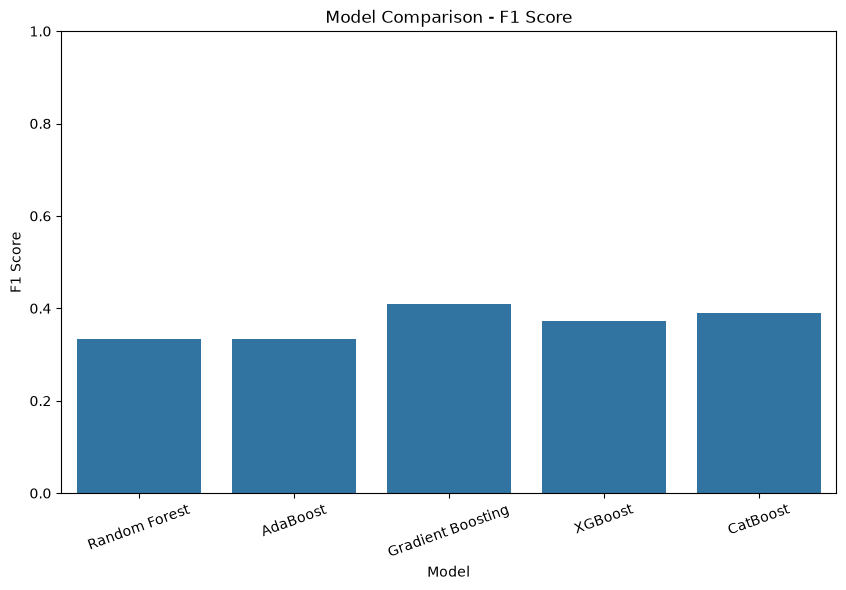

In [44]:
# ============================================================
# CELL 74 - MODEL COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison - F1 Score")

plt.xlabel("Model")

plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.ylim(0, 1)

plt.show()

## Cell 75 — Select the Best Model

We select the model with the highest F1 Score.

The selection is automatic, so we do not assume
which model is best before seeing the actual results.

In [45]:
# ============================================================
# CELL 76 - SELECT BEST MODEL
# ============================================================

best_model_name = model_results.loc[
    model_results["F1 Score"].idxmax(),
    "Model"
]

best_f1 = model_results["F1 Score"].max()

print("Best model:", best_model_name)
print("Best F1 Score:", round(best_f1, 4))

Best model: Gradient Boosting
Best F1 Score: 0.4091


## Cell 77 — Check Class Imbalance

In malaria prediction, one class may contain
significantly more patients than the other.

For example:

0 → Non-Severe Malaria

1 → Severe Malaria

If the classes are unequal, the model may become biased
towards the majority class.

Next, we will use Random Oversampling to address
this problem.

In [46]:
# ============================================================
# CELL 78 - CHECK CLASS IMBALANCE
# ============================================================

print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training class distribution:
severe_maleria
0    176
1     93
Name: count, dtype: int64

Training class percentages:
severe_maleria
0    65.43
1    34.57
Name: proportion, dtype: float64


## Cell 79 — Random Oversampling

Random Oversampling increases the number of samples
in the minority class.

The goal is to create a more balanced training dataset.

Important:

We apply oversampling only to the training data.

We do NOT oversample the testing data because the test set
should represent unseen real-world data.

In [47]:
# ============================================================
# CELL 80 - RANDOM OVERSAMPLING
# ============================================================

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    random_state=42
)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train_scaled,
    y_train
)

print("Original training data:")
print(X_train_scaled.shape)

print("\nBalanced training data:")
print(X_train_balanced.shape)

print("\nOriginal class distribution:")
print(y_train.value_counts())

print("\nBalanced class distribution:")
print(y_train_balanced.value_counts())

Original training data:
(269, 17)

Balanced training data:
(352, 17)

Original class distribution:
severe_maleria
0    176
1     93
Name: count, dtype: int64

Balanced class distribution:
severe_maleria
1    176
0    176
Name: count, dtype: int64


## Cell 81 — Train Balanced Random Forest

Now we train a new Random Forest using the
balanced training dataset.

This allows us to compare the original model
with a model trained after handling class imbalance.

In [48]:
# ============================================================
# CELL 82 - BALANCED RANDOM FOREST
# ============================================================

balanced_rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

balanced_rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

balanced_rf_predictions = balanced_rf_model.predict(
    X_test_scaled
)

balanced_rf_probabilities = (
    balanced_rf_model.predict_proba(
        X_test_scaled
    )[:, 1]
)

print("Balanced Random Forest trained successfully!")

Balanced Random Forest trained successfully!


## Cell 83 — Evaluate Balanced Random Forest

Now we evaluate the balanced Random Forest.

We pay particular attention to Recall because
identifying Severe Malaria cases correctly is important.

In [49]:
# ============================================================
# CELL 84 - BALANCED RANDOM FOREST EVALUATION
# ============================================================

balanced_rf_accuracy = accuracy_score(
    y_test,
    balanced_rf_predictions
)

balanced_rf_precision = precision_score(
    y_test,
    balanced_rf_predictions,
    zero_division=0
)

balanced_rf_recall = recall_score(
    y_test,
    balanced_rf_predictions,
    zero_division=0
)

balanced_rf_f1 = f1_score(
    y_test,
    balanced_rf_predictions,
    zero_division=0
)

balanced_rf_auc = roc_auc_score(
    y_test,
    balanced_rf_probabilities
)

balanced_rf_balanced_accuracy = balanced_accuracy_score(
    y_test,
    balanced_rf_predictions
)

balanced_rf_mcc = matthews_corrcoef(
    y_test,
    balanced_rf_predictions
)

print("Balanced Random Forest Results")
print("--------------------------------")

print(
    "Accuracy:",
    round(balanced_rf_accuracy, 4)
)

print(
    "Precision:",
    round(balanced_rf_precision, 4)
)

print(
    "Recall:",
    round(balanced_rf_recall, 4)
)

print(
    "F1 Score:",
    round(balanced_rf_f1, 4)
)

print(
    "ROC-AUC:",
    round(balanced_rf_auc, 4)
)

print(
    "Balanced Accuracy:",
    round(balanced_rf_balanced_accuracy, 4)
)

print(
    "MCC:",
    round(balanced_rf_mcc, 4)
)

Balanced Random Forest Results
--------------------------------
Accuracy: 0.5882
Precision: 0.3529
Recall: 0.2609
F1 Score: 0.3
ROC-AUC: 0.5121
Balanced Accuracy: 0.5082
MCC: 0.0179


## Cell 85 — LIME Explainability

LIME stands for Local Interpretable Model-Agnostic Explanations.

LIME explains the prediction for one individual patient.

It tells us:

- Which features increased the prediction
- Which features decreased the prediction
- How strongly each feature influenced the prediction

LIME provides a local explanation, meaning it explains
one particular prediction rather than the entire model.

In [50]:
# ============================================================
# CELL 86 - INSTALL / IMPORT LIME
# ============================================================

%pip install lime -q

print("LIME package installed successfully!")

Note: you may need to restart the kernel to use updated packages.
LIME package installed successfully!


## Cell 87 — Import LIME

Now we import the LIME tabular explainer.

LIME works with tabular numerical data, so it is suitable
for our malaria prediction dataset.

In [51]:
# ============================================================
# CELL 88 - IMPORT LIME
# ============================================================

from lime.lime_tabular import LimeTabularExplainer

print("LIME imported successfully!")

LIME imported successfully!


## Cell 89 — Create LIME Explainer

We create a LIME explainer using the training data.

The explainer needs:

- Training data
- Feature names
- Class names

The classes are:

0 → Non-Severe Malaria

1 → Severe Malaria

In [52]:
# ============================================================
# CELL 90 - CREATE LIME EXPLAINER
# ============================================================

lime_explainer = LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=X_train_scaled.columns.tolist(),
    class_names=[
        "Non-Severe Malaria",
        "Severe Malaria"
    ],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer created successfully!")

LIME explainer created successfully!


## Cell 91 — Select a Patient for Explanation

We select one patient from the test dataset.

LIME will explain why the model predicted the result
for this particular patient.

In [53]:
# ============================================================
# CELL 92 - SELECT TEST PATIENT
# ============================================================

patient_index = 0

patient_data = X_test_scaled.iloc[
    patient_index
].values

actual_value = y_test.iloc[
    patient_index
]

print("Patient selected:", patient_index)

print("Actual class:", actual_value)

Patient selected: 0
Actual class: 1


## Cell 93 — Explain the Patient Prediction

Now LIME creates an explanation for the selected patient.

We use the Random Forest model because it was already
trained successfully and provides probability predictions.

In [54]:
# ============================================================
# CELL 94 - LIME EXPLANATION
# ============================================================

lime_explanation = lime_explainer.explain_instance(
    patient_data,
    rf_model.predict_proba,
    num_features=min(
        10,
        X_test_scaled.shape[1]
    )
)

print("LIME explanation created successfully!")

LIME explanation created successfully!


## Cell 95 — Display LIME Explanation

Instead of using:

`show_in_notebook()`

we use the HTML representation directly.

This avoids the IPython `display` import error
that occurred earlier.

In [55]:
# ============================================================
# CELL 96 - DISPLAY LIME EXPLANATION
# ============================================================

from IPython.display import display, HTML

lime_html = lime_explanation.as_html()

display(
    HTML(lime_html)
)

## Cell 97 — Display LIME Explanation as a Table

We also create a simple table containing the
important features and their LIME weights.

Positive values support the prediction.

Negative values oppose the prediction.

In [56]:
# ============================================================
# CELL 98 - LIME EXPLANATION TABLE
# ============================================================

lime_list = lime_explanation.as_list()

lime_table = pd.DataFrame(
    lime_list,
    columns=[
        "Feature",
        "LIME Weight"
    ]
)

display(lime_table)

,Feature,LIME Weight
0,hyperpyrexia <= -0.37,0.094221
1,-0.69 < diarrhea <= 1.45,0.087300
2,rigor <= -0.72,-0.082188
3,age > 0.57,0.070923
4,prostraction <= -0.55,0.062248
5,-0.94 < fatigue <= 1.07,0.036361
6,vomitting <= -0.28,-0.036254
7,Convulsion <= -0.73,0.012446
8,-0.81 < bitter_tongue <= 1.23,-0.006968
9,Anemia <= -0.73,-0.006159


## Cell 99 — Interpret the LIME Result

The LIME table shows the contribution of each feature.

A positive LIME weight means the feature supports
the predicted class.

A negative LIME weight means the feature works
against the predicted class.

The magnitude of the value indicates the strength
of the contribution.

## Cell 100 — LIME Feature Contribution Graph

We now visualize the LIME feature contributions.

This graph makes the explanation easier to understand.

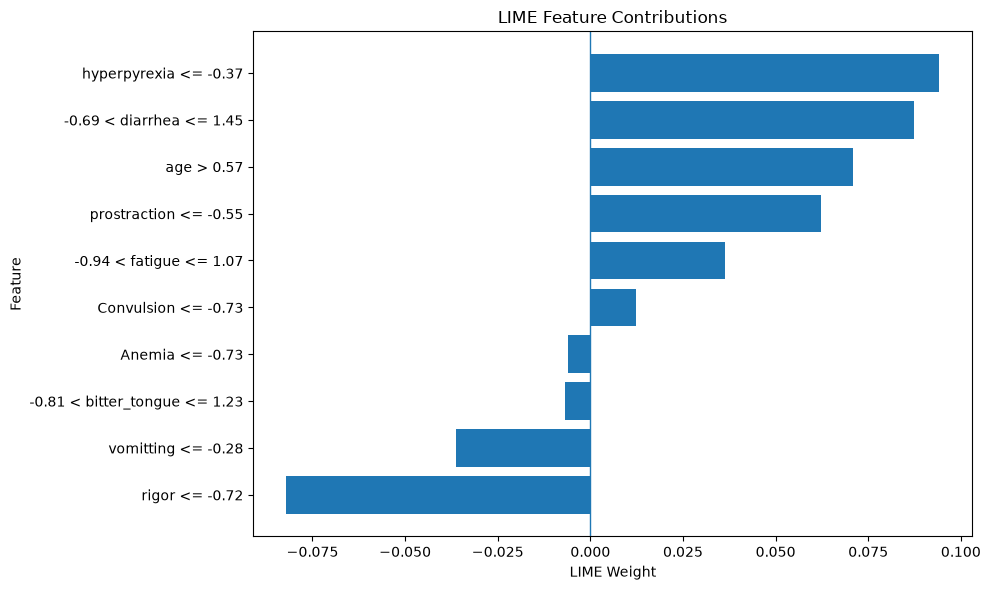

In [57]:
# ============================================================
# CELL 101 - LIME GRAPH
# ============================================================

lime_plot_data = lime_table.copy()

lime_plot_data = lime_plot_data.sort_values(
    by="LIME Weight"
)

plt.figure(figsize=(10, 6))

plt.barh(
    lime_plot_data["Feature"],
    lime_plot_data["LIME Weight"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title(
    "LIME Feature Contributions"
)

plt.xlabel(
    "LIME Weight"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

## Cell 102 — LIME Prediction

Finally, we display the model's prediction
and the actual value for the selected patient.

Class:

0 → Non-Severe Malaria

1 → Severe Malaria

In [58]:
# ============================================================
# CELL 103 - LIME PREDICTION
# ============================================================

patient_prediction = rf_model.predict(
    patient_data.reshape(1, -1)
)[0]

patient_probability = rf_model.predict_proba(
    patient_data.reshape(1, -1)
)[0]

print("Actual class:", actual_value)

print("Predicted class:", patient_prediction)

print(
    "Probability of Non-Severe Malaria:",
    round(patient_probability[0] * 100, 2),
    "%"
)

print(
    "Probability of Severe Malaria:",
    round(patient_probability[1] * 100, 2),
    "%"
)

Actual class: 1
Predicted class: 0
Probability of Non-Severe Malaria: 50.0 %
Probability of Severe Malaria: 50.0 %


## Cell 104 — SHAP Explainability

SHAP stands for SHapley Additive exPlanations.

SHAP explains how each feature contributes to a Machine
Learning prediction.

Unlike LIME, SHAP can provide both:

- Global explanations — which features are important overall
- Local explanations — why one patient's prediction was made

Here we will use SHAP with the Random Forest model.

In [59]:
import numpy

print(numpy.__version__)
print(numpy.__file__)

2.4.2
C:\Users\pamba\AppData\Roaming\Python\Python314\site-packages\numpy\__init__.py


In [60]:
import numba

print(numba.__version__)

0.65.1


In [61]:


import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

import shap

print("Required libraries imported successfully!")

Required libraries imported successfully!


## Cell 105 — SHAP Explainer

We create a SHAP TreeExplainer using the trained Random Forest model.

SHAP will be used to understand how different features influence the model's predictions.

In [62]:
# ============================================================
# CELL 106 - CREATE SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(
    balanced_rf_model
)

print("SHAP Explainer created successfully!")

SHAP Explainer created successfully!


## Cell 107 — Calculate SHAP Values

Now we calculate SHAP values for the test dataset.

SHAP values show how strongly each feature contributes
to the model's prediction.

Positive values push the prediction toward Severe Malaria.

Negative values push the prediction away from Severe Malaria.

In [63]:
# ============================================================
# CELL 108 - CALCULATE SHAP VALUES
# ============================================================

shap_values = explainer.shap_values(
    X_test_scaled
)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


## Cell 109 — Check SHAP Values

SHAP can return values in different formats depending on
the installed SHAP version.

We check the returned format before creating the plots.

In [64]:
# ============================================================
# CELL 110 - CHECK SHAP VALUES
# ============================================================

print("Type of SHAP values:")
print(type(shap_values))

if isinstance(shap_values, list):

    print("\nSHAP returned a list.")

    for i, value in enumerate(shap_values):
        print(
            "Class",
            i,
            "shape:",
            value.shape
        )

else:

    print("\nSHAP returned an array.")
    print("Shape:", shap_values.shape)

Type of SHAP values:
<class 'numpy.ndarray'>

SHAP returned an array.
Shape: (68, 17, 2)


## Cell 111 — Select Severe Malaria SHAP Values

The SHAP output contains values for two classes.

Class 0 = Non-Severe Malaria

Class 1 = Severe Malaria

For this project, we select Class 1 because it represents
the Severe Malaria prediction.

In [65]:
# ============================================================
# CELL 112 - SELECT SEVERE MALARIA SHAP VALUES
# ============================================================

shap_values_severe = shap_values[:, :, 1]

print("Severe Malaria SHAP values selected successfully!")

print(
    "SHAP shape:",
    shap_values_severe.shape
)

print(
    "Test data shape:",
    X_test_scaled.shape
)

Severe Malaria SHAP values selected successfully!
SHAP shape: (68, 17)
Test data shape: (68, 17)


## Cell 113 — SHAP Summary Plot

The SHAP summary plot shows how the features influence
the Severe Malaria predictions across all test patients.

Features at the top are generally more important.

Each point represents a patient.

The position of a point shows whether the feature
increases or decreases the prediction.

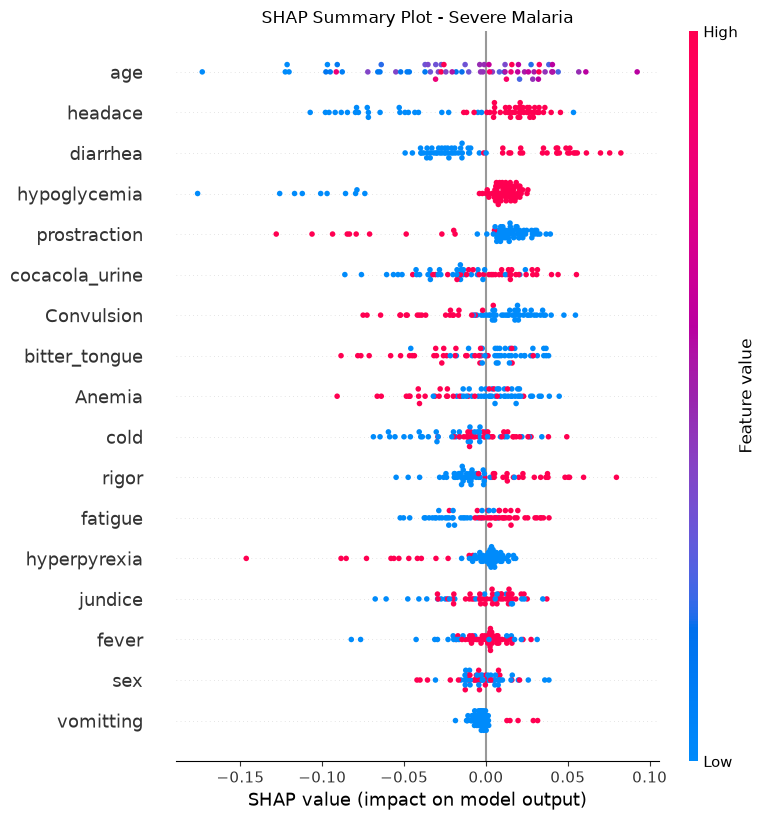

In [67]:
# ============================================================
# CELL 114 - SHAP SUMMARY PLOT
# ============================================================

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_severe,
    X_test_scaled,
    show=False
)

plt.title(
    "SHAP Summary Plot - Severe Malaria"
)

plt.tight_layout()

plt.show()

## Cell 115 — SHAP Feature Importance

We calculate the average absolute SHAP value
for every feature.

A larger value means that the feature has a greater
overall influence on the model's predictions.

In [68]:
# ============================================================
# CELL 116 - SHAP FEATURE IMPORTANCE
# ============================================================

mean_shap_importance = np.mean(
    np.abs(shap_values_severe),
    axis=0
)

shap_importance = pd.DataFrame({
    "Feature": X_test_scaled.columns,
    "Mean Absolute SHAP": mean_shap_importance
})

shap_importance = shap_importance.sort_values(
    by="Mean Absolute SHAP",
    ascending=False
)

display(
    shap_importance.head(17)
)

,Feature,Mean Absolute SHAP
0,age,0.041601
6,headace,0.034822
9,diarrhea,0.031240
14,hypoglycemia,0.025644
15,prostraction,0.025119
13,cocacola_urine,0.023864
10,Convulsion,0.023047
7,bitter_tongue,0.022974
11,Anemia,0.020673
3,cold,0.019769


## Cell 117 — SHAP Feature Importance Graph

This graph displays the features with the greatest
overall influence on Severe Malaria predictions.

Higher SHAP values indicate greater importance.

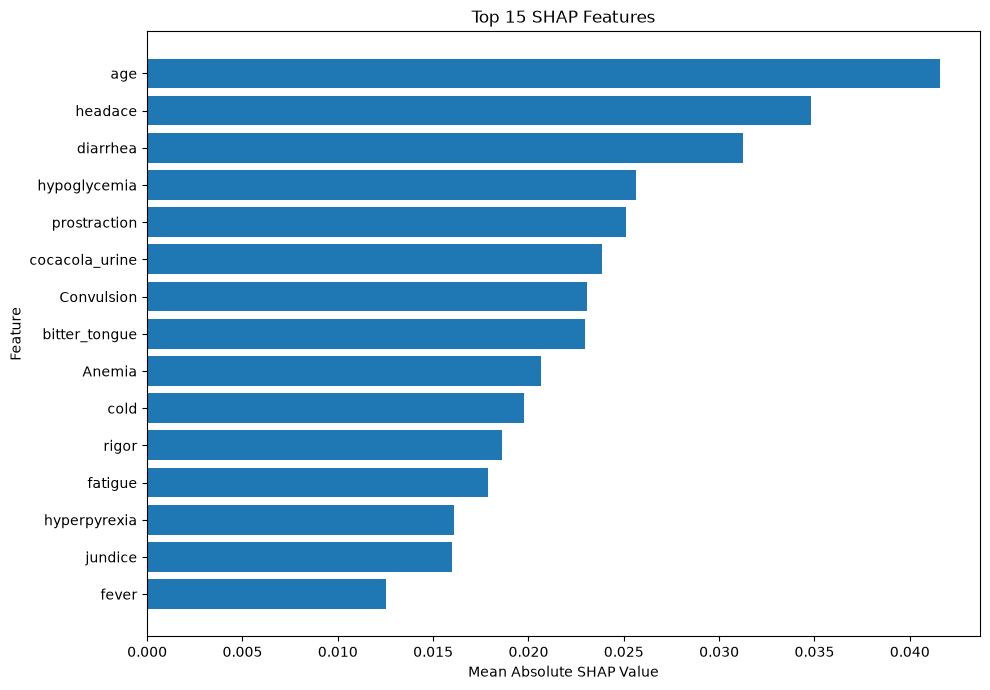

In [69]:
# ============================================================
# CELL 118 - SHAP FEATURE IMPORTANCE GRAPH
# ============================================================

top_shap_features = shap_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_shap_features["Feature"][::-1],
    top_shap_features["Mean Absolute SHAP"][::-1]
)

plt.title(
    "Top 15 SHAP Features"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

## Cell 119 — Select a Patient for SHAP Explanation

Now we select one patient from the test dataset.

We will use SHAP to explain why the Balanced Random Forest
model made its prediction for this particular patient.

In [70]:
# ============================================================
# CELL 120 - SELECT PATIENT
# ============================================================

patient_index = 0

patient_data = X_test_scaled.iloc[
    patient_index:patient_index + 1
]

actual_class = y_test.iloc[patient_index]

predicted_class = balanced_rf_model.predict(
    patient_data
)[0]

prediction_probability = balanced_rf_model.predict_proba(
    patient_data
)[0]

print("Patient index:", patient_index)

print(
    "Actual class:",
    "Severe Malaria"
    if actual_class == 1
    else "Non-Severe Malaria"
)

print(
    "Predicted class:",
    "Severe Malaria"
    if predicted_class == 1
    else "Non-Severe Malaria"
)

print(
    "Probability of Non-Severe Malaria:",
    round(prediction_probability[0] * 100, 2),
    "%"
)

print(
    "Probability of Severe Malaria:",
    round(prediction_probability[1] * 100, 2),
    "%"
)

Patient index: 0
Actual class: Severe Malaria
Predicted class: Non-Severe Malaria
Probability of Non-Severe Malaria: 54.5 %
Probability of Severe Malaria: 45.5 %


## Cell 121 — Calculate SHAP Values for the Patient

Now we calculate SHAP values for the selected patient.

These values show how each feature contributed to this
specific patient's prediction.

In [71]:
# ============================================================
# CELL 122 - PATIENT SHAP VALUES
# ============================================================

patient_shap_values = explainer.shap_values(
    patient_data
)

print(
    "Patient SHAP values calculated successfully!"
)

print(
    "SHAP output shape:",
    patient_shap_values.shape
)

Patient SHAP values calculated successfully!
SHAP output shape: (1, 17, 2)


## Cell 123 — Select Severe Malaria Contribution

The third dimension represents the two classes.

Class 0 = Non-Severe Malaria

Class 1 = Severe Malaria

We select Class 1 to understand the features contributing
to the Severe Malaria prediction.

In [72]:
# ============================================================
# CELL 124 - SELECT CLASS 1 SHAP VALUES
# ============================================================

patient_shap_severe = patient_shap_values[
    0, :, 1
]

print(
    "Severe Malaria SHAP values extracted successfully!"
)

print(
    "Number of feature contributions:",
    len(patient_shap_severe)
)

Severe Malaria SHAP values extracted successfully!
Number of feature contributions: 17


## Cell 125 — Patient SHAP Contribution Table

This table shows the contribution of every feature
to the selected patient's Severe Malaria prediction.

Positive SHAP value:
The feature pushes the prediction toward Severe Malaria.

Negative SHAP value:
The feature pushes the prediction away from Severe Malaria.

Larger absolute values indicate stronger influence.

In [73]:
# ============================================================
# CELL 126 - PATIENT SHAP TABLE
# ============================================================

patient_shap_table = pd.DataFrame({
    "Feature": X_test_scaled.columns,
    "SHAP Value": patient_shap_severe
})

patient_shap_table["Absolute SHAP"] = (
    patient_shap_table["SHAP Value"].abs()
)

patient_shap_table = patient_shap_table.sort_values(
    by="Absolute SHAP",
    ascending=False
)

display(patient_shap_table)

,Feature,SHAP Value,Absolute SHAP
6,headace,-0.098044,0.098044
9,diarrhea,0.043262,0.043262
15,prostraction,0.030965,0.030965
7,bitter_tongue,-0.025971,0.025971
0,age,0.019391,0.019391
1,sex,-0.012647,0.012647
16,hyperpyrexia,0.011721,0.011721
4,rigor,-0.011047,0.011047
5,fatigue,0.009767,0.009767
8,vomitting,-0.006779,0.006779


## Cell 127 — Top Features for This Patient

Now we display the 10 features that had the strongest
influence on this patient's prediction.

In [74]:
# ============================================================
# CELL 128 - TOP PATIENT FEATURES
# ============================================================

top_patient_features = patient_shap_table.head(10)

display(top_patient_features)

,Feature,SHAP Value,Absolute SHAP
6,headace,-0.098044,0.098044
9,diarrhea,0.043262,0.043262
15,prostraction,0.030965,0.030965
7,bitter_tongue,-0.025971,0.025971
0,age,0.019391,0.019391
1,sex,-0.012647,0.012647
16,hyperpyrexia,0.011721,0.011721
4,rigor,-0.011047,0.011047
5,fatigue,0.009767,0.009767
8,vomitting,-0.006779,0.006779


## Cell 129 — Patient SHAP Visualization

The following graph shows the strongest feature contributions
for the selected patient.

Features with positive SHAP values support the
Severe Malaria prediction.

Features with negative SHAP values oppose it.

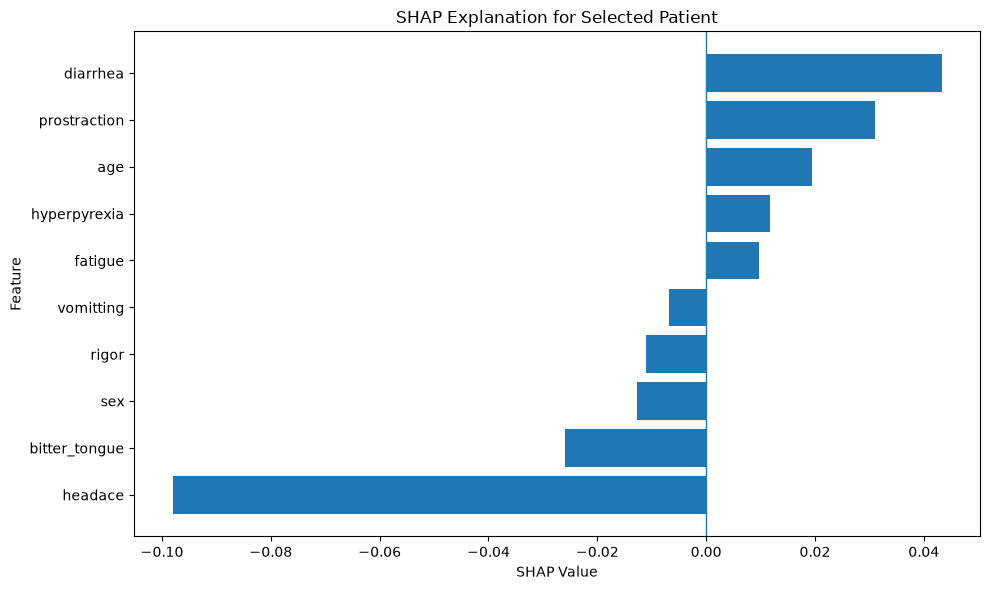

In [76]:
# ============================================================
# CELL 130 - PATIENT SHAP GRAPH
# ============================================================

patient_plot_data = (
    patient_shap_table
    .head(10)
    .sort_values(
        by="SHAP Value"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    patient_plot_data["Feature"],
    patient_plot_data["SHAP Value"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title(
    "SHAP Explanation for Selected Patient"
)

plt.xlabel(
    "SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

## Cell 131 — Compare LIME and SHAP

We have now used two explainability techniques.

### LIME

LIME explains an individual prediction by creating
a local approximation around that patient.

### SHAP

SHAP calculates the contribution of each feature
to the model prediction.

Both methods help make the Machine Learning model
more interpretable.

In [77]:
# ============================================================
# CELL 132 - FINAL PATIENT EXPLANATION SUMMARY
# ============================================================

print("==============================================")
print("       PATIENT EXPLANATION SUMMARY")
print("==============================================")

print(
    "Actual:",
    "Severe Malaria"
    if actual_class == 1
    else "Non-Severe Malaria"
)

print(
    "Predicted:",
    "Severe Malaria"
    if predicted_class == 1
    else "Non-Severe Malaria"
)

print(
    "Severe Malaria Probability:",
    round(prediction_probability[1] * 100, 2),
    "%"
)

print("\nTop 5 influential features:")

display(
    patient_shap_table.head(5)
)

print("==============================================")

       PATIENT EXPLANATION SUMMARY
Actual: Severe Malaria
Predicted: Non-Severe Malaria
Severe Malaria Probability: 45.5 %

Top 5 influential features:


,Feature,SHAP Value,Absolute SHAP
6,headace,-0.098044,0.098044
9,diarrhea,0.043262,0.043262
15,prostraction,0.030965,0.030965
7,bitter_tongue,-0.025971,0.025971
0,age,0.019391,0.019391


## Cell 133 — Select Final Model

We now select the final model for the malaria prediction system.

The Balanced Random Forest was trained after handling
class imbalance using Random Oversampling.

We will use this model for the final prediction system.

In [79]:
# ============================================================
# CELL 134 - FINAL MODEL
# ============================================================

final_model = balanced_rf_model

print("Final model selected:")
print("Balanced Random Forest")

Final model selected:
Balanced Random Forest


## Cell 135 — Save the Final Model

We save the trained model so that it can be reused later
without training the model again.

We also save:

- The scaler
- Feature names

These are required when making predictions on new patient data.

In [80]:
# ============================================================
# CELL 136 - SAVE MODEL
# ============================================================

import os
import joblib

MODEL_DIR = "saved_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

joblib.dump(
    final_model,
    os.path.join(
        MODEL_DIR,
        "malaria_balanced_random_forest.pkl"
    )
)

joblib.dump(
    scaler,
    os.path.join(
        MODEL_DIR,
        "malaria_scaler.pkl"
    )
)

joblib.dump(
    X_train_scaled.columns.tolist(),
    os.path.join(
        MODEL_DIR,
        "malaria_feature_names.pkl"
    )
)

print("Model saved successfully!")
print("Scaler saved successfully!")
print("Feature names saved successfully!")

Model saved successfully!
Scaler saved successfully!
Feature names saved successfully!


## Cell 137 — Load the Saved Model

We now test whether the saved model can be loaded correctly.

This is important because the saved model will later
be used by the application.

In [81]:
# ============================================================
# CELL 138 - LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    os.path.join(
        MODEL_DIR,
        "malaria_balanced_random_forest.pkl"
    )
)

loaded_scaler = joblib.load(
    os.path.join(
        MODEL_DIR,
        "malaria_scaler.pkl"
    )
)

loaded_feature_names = joblib.load(
    os.path.join(
        MODEL_DIR,
        "malaria_feature_names.pkl"
    )
)

print("Saved model loaded successfully!")
print("Saved scaler loaded successfully!")
print("Feature names loaded successfully!")

print(
    "\nNumber of features:",
    len(loaded_feature_names)
)

Saved model loaded successfully!
Saved scaler loaded successfully!
Feature names loaded successfully!

Number of features: 17


## Cell 139 — Test the Saved Model

Before using new patient information, we test the loaded
model on the existing test dataset.

The prediction should work without retraining the model.

In [82]:
# ============================================================
# CELL 140 - TEST LOADED MODEL
# ============================================================

loaded_predictions = loaded_model.predict(
    X_test_scaled
)

loaded_probabilities = loaded_model.predict_proba(
    X_test_scaled
)

loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

print(
    "Loaded model accuracy:",
    round(loaded_accuracy, 4)
)

print(
    "Loaded model tested successfully!"
)

Loaded model accuracy: 0.5882
Loaded model tested successfully!


## Cell 141 — New Patient Prediction

Now we create a function that can predict malaria
for a new patient.

The function will:

1. Receive patient feature values
2. Convert them into the correct format
3. Apply the saved scaler
4. Make a prediction
5. Display prediction probabilities

In [84]:
# ============================================================
# CELL 142 - NEW PATIENT PREDICTION FUNCTION
# ============================================================

def predict_malaria(patient_values):

    patient_df = pd.DataFrame(
        [patient_values],
        columns=loaded_feature_names
    )

    patient_scaled = loaded_scaler.transform(
        patient_df
    )

    prediction = loaded_model.predict(
        patient_scaled
    )[0]

    probabilities = loaded_model.predict_proba(
        patient_scaled
    )[0]

    print("==============================================")
    print("          MALARIA PREDICTION")
    print("==============================================")

    if prediction == 1:

        print("Prediction: Severe Malaria")

    else:

        print("Prediction: Non-Severe Malaria")

    print(
        "Non-Severe Probability:",
        round(probabilities[0] * 100, 2),
        "%"
    )

    print(
        "Severe Probability:",
        round(probabilities[1] * 100, 2),
        "%"
    )

    print("==============================================")

    return prediction, probabilities

## Cell 143 — Test the Prediction Function

The function created in the previous cell will now be
called using one patient from the test dataset.

This verifies that the saved model can make a prediction
for a new patient.

In [85]:
# ============================================================
# CELL 144 - TEST NEW PATIENT PREDICTION
# ============================================================

# Take the first patient from the original test dataset
new_patient = X_test.iloc[0].to_dict()

print("New patient data:")
display(
    pd.DataFrame([new_patient])
)

# Call the prediction function
prediction, probabilities = predict_malaria(
    new_patient
)

New patient data:


,age,sex,fever,cold,rigor,fatigue,headace,bitter_tongue,vomitting,diarrhea,Convulsion,Anemia,jundice,cocacola_urine,hypoglycemia,prostraction,hyperpyrexia
0,42,1,1,1,0,1,0,1,0,1,0,0,1,1,1,0,0


          MALARIA PREDICTION
Prediction: Non-Severe Malaria
Non-Severe Probability: 54.5 %
Severe Probability: 45.5 %


## Cell 145 — Prediction Probability Visualization

The following graph displays the predicted probability
for each malaria class.

Class 0 = Non-Severe Malaria

Class 1 = Severe Malaria

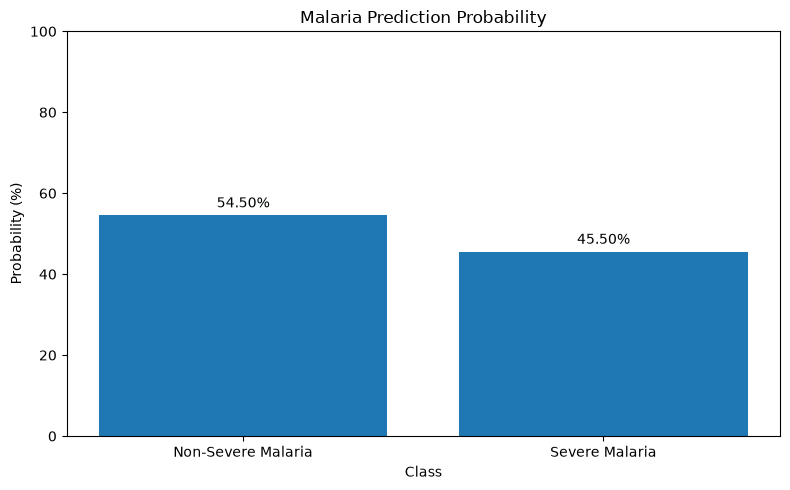

In [86]:
# ============================================================
# CELL 146 - PREDICTION PROBABILITY GRAPH
# ============================================================

class_names = [
    "Non-Severe Malaria",
    "Severe Malaria"
]

probability_percentages = probabilities * 100

plt.figure(figsize=(8, 5))

plt.bar(
    class_names,
    probability_percentages
)

plt.title("Malaria Prediction Probability")

plt.xlabel("Class")

plt.ylabel("Probability (%)")

plt.ylim(0, 100)

for i, value in enumerate(probability_percentages):
    plt.text(
        i,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.show()

## Cell 147 — Final Prediction Report

This cell generates a simple final report for the
selected patient.

It shows:

- Prediction
- Non-Severe Malaria probability
- Severe Malaria probability

In [88]:
# ============================================================
# CELL 148 - FINAL PREDICTION REPORT
# ============================================================

print("=" * 55)
print("             MALARIA PREDICTION REPORT")
print("=" * 55)

if prediction == 1:
    result = "Severe Malaria"
else:
    result = "Non-Severe Malaria"

print("Prediction:", result)

print(
    "Non-Severe Malaria Probability:",
    f"{probabilities[0] * 100:.2f}%"
)

print(
    "Severe Malaria Probability:",
    f"{probabilities[1] * 100:.2f}%"
)

print("=" * 55)

             MALARIA PREDICTION REPORT
Prediction: Non-Severe Malaria
Non-Severe Malaria Probability: 54.50%
Severe Malaria Probability: 45.50%


## Cell 149 — Project Completion Summary

The complete Malaria Prediction Machine Learning project
has now been implemented.

The project includes:

1. Dataset loading
2. Data cleaning
3. Missing-value analysis
4. Exploratory Data Analysis
5. Correlation analysis
6. Feature preparation
7. Train-test split
8. Feature scaling
9. Random Forest
10. AdaBoost
11. Gradient Boosting
12. XGBoost
13. CatBoost
14. Model comparison
15. Class imbalance analysis
16. Random Oversampling
17. Balanced Random Forest
18. LIME explainability
19. SHAP global explainability
20. SHAP patient-level explainability
21. Model saving
22. Model loading
23. New patient prediction
24. Prediction probability visualization

In [89]:
# ============================================================
# CELL 150 - PROJECT COMPLETION
# ============================================================

print("=" * 60)
print("        MALARIA PREDICTION PROJECT")
print("=" * 60)

print()
print("Data Analysis          : COMPLETED")
print("Data Preprocessing     : COMPLETED")
print("Model Training         : COMPLETED")
print("Model Comparison       : COMPLETED")
print("Class Balancing        : COMPLETED")
print("LIME Explainability    : COMPLETED")
print("SHAP Explainability    : COMPLETED")
print("Patient Explanation   : COMPLETED")
print("Model Saving           : COMPLETED")
print("Model Loading          : COMPLETED")
print("New Patient Prediction : COMPLETED")
print()
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

        MALARIA PREDICTION PROJECT

Data Analysis          : COMPLETED
Data Preprocessing     : COMPLETED
Model Training         : COMPLETED
Model Comparison       : COMPLETED
Class Balancing        : COMPLETED
LIME Explainability    : COMPLETED
SHAP Explainability    : COMPLETED
Patient Explanation   : COMPLETED
Model Saving           : COMPLETED
Model Loading          : COMPLETED
New Patient Prediction : COMPLETED

PROJECT COMPLETED SUCCESSFULLY!
